# Introduction to Convolutional Neural Networks - Image analysis

## Overview

This kernel is aimed at giving a simple understanding of a Convolutional Neural Network (CNN). This will be achieved in the following order:

- Understanding the operation of convolution
- A short look back Neural Networks
- Data preprocessing
- Understanding the Convolutional Neural Network used
- Understanding Optimizers
- Understanding ImageDataGenerator
- Making the predictions and calculating the accuracy

## What is Convolution?

<b>Definition:</b>
   - In mathematics, convolution is a mathematical operation between two functions (f and g) to produce a third function that expresses how the shape of one is modified by the other.

<b>Utility:</b>
   - Convolution is used in several areas such as probability, statistics, computer vision, natural language processing, image and signal processing, engineering, and differential equations.


## What are Artificial Neural Networks?

<b>Definition: </b>
   - Artificial neural networks (ANN) or connectionist systems are computing systems vaguely inspired by the biological neural networks that constitute animal brains. Such systems "learn" to perform tasks by considering examples, generally without being programmed with any task-specific rules.
   - An ANN is a collection of smaller processing units called the artificial neurons which loosely resemble the biological neuron.
   - A collection of interconnected circuits make a network. </b>

## What are Convolutional Neural Networks

<b>Definition:</b>
   - In deep learning, a convolutional neural network (CNN, or ConvNet) is a class of artificial neural network (ANN), most commonly applied to analyze visual imagery.
   - CNNs were inspired by biological processes in that the connectivity pattern between neurons resembles the organization of the animal visual cortex.
   - A CNN architecture is formed by a stack of distinct layers that transform the input volume into an output volume through a differentiable function. A few distinct types of layers are commonly used.
   
<b>Convolutional layer:</b>
   - The convolutional layer is the core building block of a CNN. The layer's parameters consist of a set of learnable filters (or kernels), which have a small receptive field, but extend through the full depth of the input volume.
   - During the forward pass, each filter is convolved across the width and height of the input volume, computing the dot product between the filter entries and the input, producing a 2-dimensional activation map of that filter. As a result, the network learns filters that activate when it detects some specific type of feature at some spatial position in the input.
      
      <img src="https://miro.medium.com/max/1400/1*Fw-ehcNBR9byHtho-Rxbtw.gif" width="500" height="340">
      
<b>Pooling Layer</b>
   - There are several non-linear functions to implement pooling, where max pooling is the most common.
   - It partitions the input image into a set of rectangles and, for each such sub-region, outputs the maximum.
   
   <img src="https://nico-curti.github.io/NumPyNet/NumPyNet/images/maxpool.gif" width="500" height="340">

In [1]:
import torch
from torch import nn,optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

MNIST Dataset:
  - handwritten digits
  - classification
  
https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST

In [2]:
import random
import matplotlib.pyplot as plt
from torchvision import datasets

raw_train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
)

raw_test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
)

In [3]:
raw_train_dataset[0]

(<PIL.Image.Image image mode=L size=28x28>, 5)

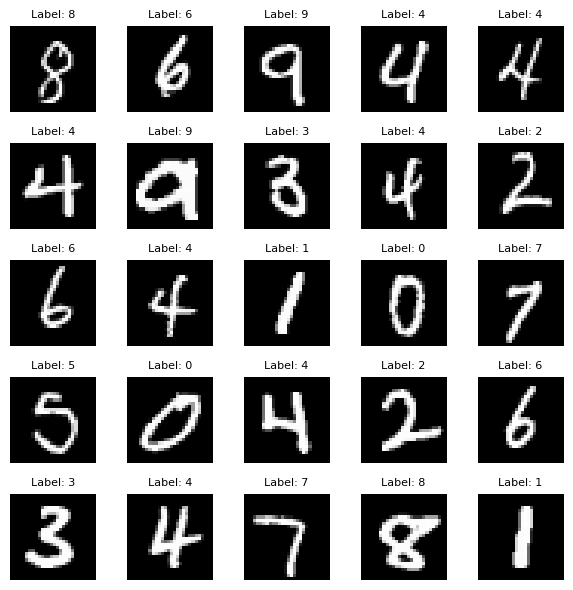

In [4]:
def show_random_raw_mnist_images(dataset, n=25):
    indices = random.sample(range(len(dataset)), n)

    rows = int(n ** 0.5)
    cols = rows

    if rows * cols < n:
        cols += 1

    fig, axes = plt.subplots(rows, cols, figsize=(6, 6))
    axes = axes.flatten()

    for ax, idx in zip(axes, indices):
        image, label = dataset[idx]

        ax.imshow(image, cmap="gray")
        ax.set_title(f"Label: {label}", fontsize=8)
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_random_raw_mnist_images(raw_train_dataset, n=25)

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [6]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False,
)

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [7]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
LR = 1e-3

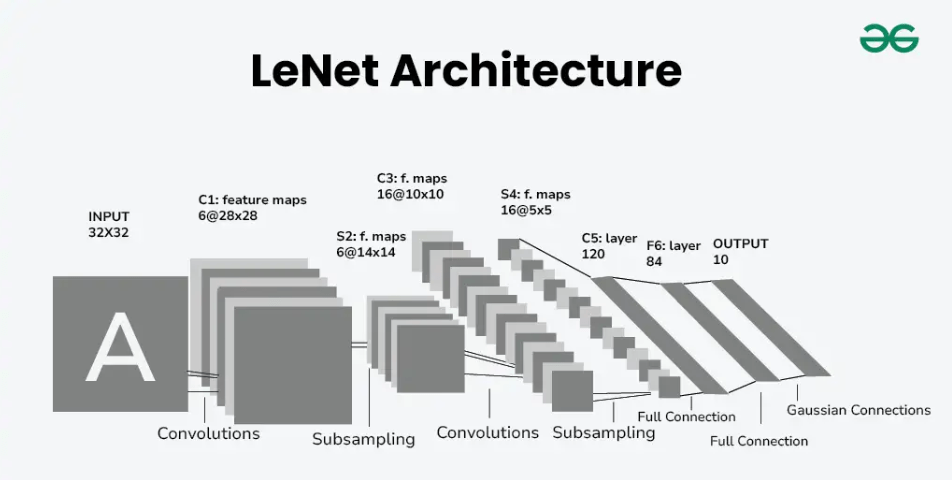

In [8]:
models = {
    "MLP": nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, 256),
        nn.ReLU(),
        nn.Linear(256, 16),
        nn.ReLU(),
        nn.Linear(16, 10),
    ),

    "LeNet": nn.Sequential(
        nn.Conv2d(1, 6, kernel_size=5),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),

        nn.Conv2d(6, 16, kernel_size=5),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),

        nn.Flatten(),
        nn.Linear(16 * 4 * 4, 120),
        nn.ReLU(),
        nn.Linear(120, 84),
        nn.ReLU(),
        nn.Linear(84, 10),
    ),
}

In [9]:
def train_one_epoch(model, train_loader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


def evaluate(model, test_loader, criterion):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = outputs.max(dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    test_loss = running_loss / total
    test_accuracy = correct / total

    return test_loss, test_accuracy


def train_model(model, model_name, num_epochs, lr):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    history = {
        "model_name": model_name,
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    print(f"\nTraining {model_name}")
    print("-" * 40)

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        test_loss, test_acc = evaluate(
            model,
            test_loader,
            criterion
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch [{epoch + 1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Train Acc: {train_acc:.4f} "
            f"Test Loss: {test_loss:.4f} "
            f"Test Acc: {test_acc:.4f}"
        )

    return history

In [10]:
histories = {
    key: train_model(models[key],key,num_epochs=5,lr=LR)
    for key in models
}


Training MLP
----------------------------------------
Epoch [1/5] Train Loss: 0.7469 Train Acc: 0.9188 Test Loss: 0.6267 Test Acc: 0.9650
Epoch [2/5] Train Loss: 0.6012 Train Acc: 0.9725 Test Loss: 0.5885 Test Acc: 0.9753
Epoch [3/5] Train Loss: 0.5749 Train Acc: 0.9816 Test Loss: 0.5802 Test Acc: 0.9787
Epoch [4/5] Train Loss: 0.5603 Train Acc: 0.9863 Test Loss: 0.5792 Test Acc: 0.9768
Epoch [5/5] Train Loss: 0.5515 Train Acc: 0.9899 Test Loss: 0.5677 Test Acc: 0.9821

Training LeNet
----------------------------------------
Epoch [1/5] Train Loss: 0.7092 Train Acc: 0.9344 Test Loss: 0.5746 Test Acc: 0.9814
Epoch [2/5] Train Loss: 0.5619 Train Acc: 0.9837 Test Loss: 0.5476 Test Acc: 0.9881
Epoch [3/5] Train Loss: 0.5440 Train Acc: 0.9884 Test Loss: 0.5478 Test Acc: 0.9879
Epoch [4/5] Train Loss: 0.5346 Train Acc: 0.9910 Test Loss: 0.5361 Test Acc: 0.9896
Epoch [5/5] Train Loss: 0.5287 Train Acc: 0.9924 Test Loss: 0.5340 Test Acc: 0.9885


In [11]:
import matplotlib.pyplot as plt

def plot_all_histories(histories):
    metrics = {
        "train_loss": "Training Loss",
        "test_loss": "Test Loss",
        "train_acc": "Training Accuracy",
        "test_acc": "Test Accuracy"
    }

    fig, axes = plt.subplots(2, 2, figsize=(10, 6))
    axes = axes.flatten()

    for ax, (metric_name, title) in zip(axes, metrics.items()):
        for model_name, history in histories.items():
            epochs = range(1, len(history[metric_name]) + 1)

            ax.plot(
                epochs,
                history[metric_name],
                marker="o",
                label=model_name
            )

        ax.set_xlabel("Epoch")
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.grid(True)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

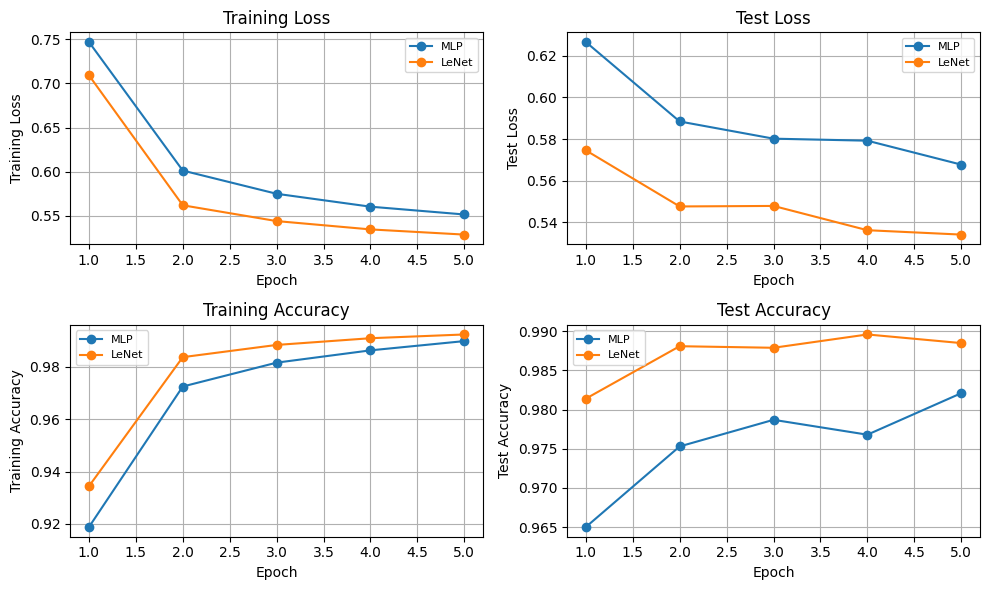

In [12]:
plot_all_histories(histories)

In [13]:
def num_params(model):
  return sum(y.numel() for y in model.parameters())

In [14]:
{key:num_params(model) for key,model in models.items()}

{'MLP': 205242, 'LeNet': 44426}

#### Visualizing the mistakes of the models

In [15]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrices_side_by_side(
    trained_models,
    test_loader,
    device,
    normalize=None,
    class_names=None
):
    if class_names is None:
        class_names = [str(i) for i in range(10)]

    num_models = len(trained_models)

    fig, axes = plt.subplots(
        1,
        num_models,
        figsize=(5 * num_models, 4)
    )

    if num_models == 1:
        axes = [axes]

    for ax, (model_name, model) in zip(axes, trained_models.items()):
        model.eval()

        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)

                outputs = model(images)
                preds = outputs.argmax(dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())

        cm = confusion_matrix(
            all_labels,
            all_preds,
            normalize=normalize
        )

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=class_names
        )

        disp.plot(
            ax=ax,
            cmap="Blues",
            colorbar=False,
            values_format=".2f" if normalize else "d"
        )

        ax.set_title(f"{model_name}")
        ax.set_xlabel("Predicted Label")
        ax.set_ylabel("True Label")

    plt.tight_layout()
    plt.show()

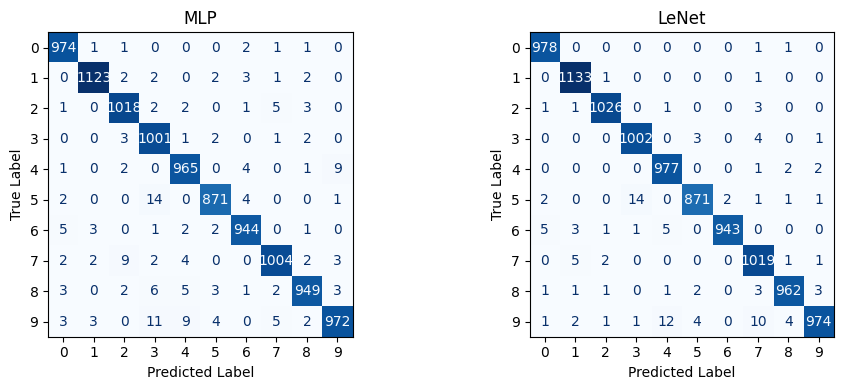

In [16]:
plot_confusion_matrices_side_by_side(
    trained_models=models,
    test_loader=test_loader,
    device=device
)

### Other applications of CNNs

- Classification
- Search (in the section below)
- Out-of-domain classification (in the section below)

In [17]:
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights
import torch
from torch import nn,optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### Download the Animal Image Dataset

https://www.kaggle.com/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals?resource=download

In [18]:
DATA_DIR = Path("./data/animals/animals/")

BATCH_SIZE = 64
NUM_WORKERS = 4

In [19]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(device)

cuda:0


In [20]:
weights = MobileNet_V3_Large_Weights.IMAGENET1K_V2
transform = weights.transforms()

base_model = mobilenet_v3_large(weights=weights)
base_model.eval()
base_model.to(device)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

In [21]:
class MobileNetV3Embedding(nn.Module):
    def __init__(self, mobilenet):
        super().__init__()
        self.features = mobilenet.features
        self.avgpool = mobilenet.avgpool
        self.classification = nn.Sequential(
        nn.Linear(960, 256),
        nn.SiLU(),
        nn.Linear(256, 256),
        nn.SiLU(),
        nn.Linear(256, 90),
    )

    def forward(self, x, return_embedding=False):
        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)
        x = self.features(x)
        x = self.avgpool(x)
        x = x.flatten(1)

        if return_embedding:
            return x

        x = self.classification(x)
        return x

In [22]:
dataset = datasets.ImageFolder(
    root=DATA_DIR,
    transform=transform,
)

# split into 2 separate train and test datasets
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# train loader and test loader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)


embedding_model = MobileNetV3Embedding(base_model)

# train freeze the feature extractor and only train the classification head

for p in embedding_model.parameters():
    p.requires_grad = False
for p in embedding_model.classification.parameters():
    p.requires_grad = True

embedding_model.to(device)

train_model(embedding_model, "MobileNetV3Embedding", num_epochs=5, lr=3e-4)



Training MobileNetV3Embedding
----------------------------------------


Epoch [1/5] Train Loss: 4.2405 Train Acc: 0.2000 Test Loss: 3.6929 Test Acc: 0.3852
Epoch [2/5] Train Loss: 2.6207 Train Acc: 0.5627 Test Loss: 2.2932 Test Acc: 0.7176
Epoch [3/5] Train Loss: 1.8268 Train Acc: 0.7667 Test Loss: 1.8087 Test Acc: 0.7750
Epoch [4/5] Train Loss: 1.5616 Train Acc: 0.8333 Test Loss: 1.6049 Test Acc: 0.8167
Epoch [5/5] Train Loss: 1.4252 Train Acc: 0.8745 Test Loss: 1.4996 Test Acc: 0.8435


{'model_name': 'MobileNetV3Embedding',
 'train_loss': [4.240506698467113,
  2.6206839755729394,
  1.8268496734124642,
  1.5616294507627133,
  1.4251795521488897],
 'train_acc': [0.2,
  0.5627314814814814,
  0.7666666666666667,
  0.8333333333333334,
  0.874537037037037],
 'test_loss': [3.692945374382867,
  2.2931851245738843,
  1.8086923440297444,
  1.6049342764748467,
  1.4995699105439362],
 'test_acc': [0.3851851851851852,
  0.7175925925925926,
  0.775,
  0.8166666666666667,
  0.8435185185185186]}

In [23]:
embedding_model.eval()
embedding_model.to(device)

MobileNetV3Embedding(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(

In [24]:


loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

train_indices = train_dataset.indices
train_image_paths = [dataset.samples[i][0] for i in train_indices]
train_labels = [dataset.samples[i][1] for i in train_indices]
class_names = dataset.classes

print("Number of images:", len(dataset))
print("Number of classes:", len(class_names))
print("Example classes:", class_names[:10])

Number of images: 5400
Number of classes: 90
Example classes: ['antelope', 'badger', 'bat', 'bear', 'bee', 'beetle', 'bison', 'boar', 'butterfly', 'cat']


In [25]:
next(iter(train_loader))[0].shape

torch.Size([64, 3, 224, 224])

In [26]:
all_embeddings = []
all_labels = []

with torch.no_grad():
    for images, batch_labels in loader:
        images = images.to(device)

        batch_embeddings = embedding_model(images, return_embedding=False)
        batch_embeddings = F.normalize(batch_embeddings, p=2, dim=1)

        all_embeddings.append(batch_embeddings.cpu())
        all_labels.append(batch_labels)

all_embeddings = torch.cat(all_embeddings, dim=0)
all_labels = torch.cat(all_labels, dim=0)

print("Embeddings shape:", all_embeddings.shape)

Embeddings shape: torch.Size([4320, 90])


In [27]:
def search_similar(query_image_path, top_k=10):
    image = Image.open(query_image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        query_emb = embedding_model(image, return_embedding=False)
        query_emb = F.normalize(query_emb, dim=1).cpu()

    similarities = query_emb @ all_embeddings.T

    scores, indices = torch.topk(similarities.squeeze(0), top_k)

    results = []

    for score, idx in zip(scores, indices):
        idx = idx.item()
        label_idx = all_labels[idx].item()

        results.append({
            "path": train_image_paths[idx],
            "class": class_names[label_idx],
            "score": score.item()
        })

    return results

In [28]:
results = search_similar("./cat.jpg", top_k=10)

for r in results:
    print(f"{r['score']:.4f} | {r['class']} | {r['path']}")

0.9604 | cat | data/animals/animals/cat/4c6ff6dae0.jpg
0.9576 | cat | data/animals/animals/cat/31ae8d36b6.jpg
0.9564 | cat | data/animals/animals/cat/3321ec48a8.jpg
0.9493 | cat | data/animals/animals/cat/0d0d6d90d8.jpg
0.9460 | cat | data/animals/animals/cat/7f923c6676.jpg
0.9443 | cat | data/animals/animals/cat/2a40de8365.jpg
0.9436 | cat | data/animals/animals/cat/3f3a2aaef2.jpg
0.9402 | cat | data/animals/animals/cat/636b432421.jpg
0.9364 | cat | data/animals/animals/cat/71756f7bd0.jpg
0.9353 | cat | data/animals/animals/cat/5e07a0666d.jpg


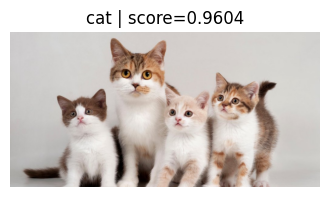

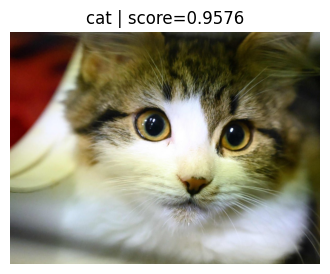

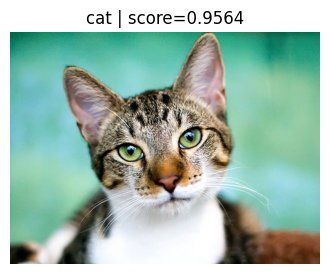

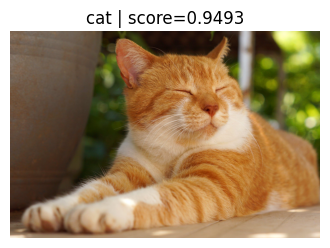

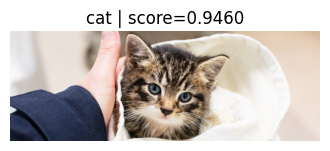

In [29]:
import matplotlib.pyplot as plt

results = search_similar("./cat.jpg", top_k=5)

for r in results:
    img = Image.open(r["path"]).convert("RGB")

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"{r['class']} | score={r['score']:.4f}")
    plt.axis("off")
    plt.show()

In [30]:
DATA_DIR = Path("./data/animals/animals/")

BATCH_SIZE = 64
NUM_WORKERS = 4

In [31]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(device)

cuda:0


In [32]:
class InceptionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False), # (299-3+2*1)/2 + 1 = 150
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1, bias=False), # (150-3+2*1)/2 + 1 = 75
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False), # (75-3+2*1)/2 + 1 = 38
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, bias=False), # (38-3+2*1)/2 + 1 = 19
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1, bias=False), # (19-3+2*1)/2 + 1 = 9
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Conv2d(512, 1280, kernel_size=5, stride=1, padding=1, bias=False), # (9-5+2*1)/1 + 1 = 8
            nn.BatchNorm2d(1280),
            nn.ReLU(inplace=True)
        )
        self.conv1 = nn.Sequential(nn.Conv2d(in_channels = 1280,out_channels = 320,kernel_size = 1, stride = 1),
        nn.BatchNorm2d(320),
        nn.ReLU(inplace=True))
        self.conv2 = nn.Sequential(nn.Conv2d(in_channels = 1280,out_channels = 384,kernel_size = 1, stride = 1),
        nn.BatchNorm2d(384),
        nn.ReLU(inplace=True))
        self.conv3 = nn.Sequential(nn.Conv2d(in_channels = 1280,out_channels = 448,kernel_size = 1, stride = 1),
        nn.BatchNorm2d(448),
        nn.ReLU(inplace=True))
        self.conv4 = nn.Sequential(nn.Conv2d(in_channels = 384,out_channels = 384, kernel_size = (1,3), padding=(0, 1), stride = 1),
        nn.BatchNorm2d(384),
        nn.ReLU(inplace=True))
        self.conv5 = nn.Sequential(nn.Conv2d(in_channels = 384,out_channels = 384, kernel_size = (3,1), padding=(1, 0), stride = 1),
        nn.BatchNorm2d(384),
        nn.ReLU(inplace=True))
        self.conv6 = nn.Sequential(nn.Conv2d(in_channels = 448,out_channels = 384, kernel_size = 3, padding = 1, stride = 1),
        nn.BatchNorm2d(384),
        nn.ReLU(inplace=True))
        self.conv7 = nn.Sequential(nn.Conv2d(in_channels = 1280,out_channels = 192, kernel_size = 1, stride = 1),
        nn.BatchNorm2d(192),
        nn.ReLU(inplace=True))
        self.conv8 = nn.Sequential(nn.Conv2d(in_channels = 384,out_channels = 384, kernel_size = (1,3), padding=(0, 1), stride = 1),
        nn.BatchNorm2d(384),
        nn.ReLU(inplace=True))
        self.conv9 = nn.Sequential(nn.Conv2d(in_channels = 384,out_channels = 384, kernel_size = (3,1), padding=(1, 0), stride = 1),
        nn.BatchNorm2d(384),
        nn.ReLU(inplace=True))
        self.avgpool = nn.AvgPool2d(kernel_size=3, padding=1, stride=1)
        self.fc1 = nn.Linear(2048, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 90)
        self.dropout1 = nn.Dropout(0.1)
        self.dropout2 = nn.Dropout(0.1)
        self.dropout_spatial = nn.Dropout2d(p=0.1)


    def forward(self, x):
        x = self.features(x)
        x_a = self.conv1(x)
        x_b = self.conv2(x)
        x_c = self.conv3(x)
        x_d = self.avgpool(x)
        x_d = self.conv7(x_d)
        x_b1 = self.conv4(x_b)
        x_b2 = self.conv5(x_b)
        x_c = self.conv6(x_c)
        x_c1 = self.conv8(x_c)
        x_c2 = self.conv9(x_c)
        x_b_cat = torch.cat([x_b1, x_b2], dim=1)
        x_c_cat = torch.cat([x_c1, x_c2], dim=1)
        out = torch.cat([x_a, x_b_cat, x_c_cat, x_d], dim=1)
        out = self.dropout_spatial(out)
        out = F.adaptive_avg_pool2d(out, (1, 1)).flatten(1)
        out = self.fc1(out)
        out = F.relu(out, inplace=True)
        out = self.dropout1(out)
        out = self.fc2(out)
        out = F.relu(out, inplace=True)
        out = self.dropout2(out)
        out = self.fc3(out)
        return out

In [33]:
#define a [b_size, 3, 64, 64] tensor and pass it through the inceptionnet architecture defined above. print the shape of each intermediate tensor to see how the data flows through the network. make sure the final output shape is correct according to the architecture defined above.

test_tensor = torch.randn(BATCH_SIZE, 3, 299, 299).to(device)
inception_net = InceptionNet().to(device)
with torch.no_grad():
    print("Input shape:", test_tensor.shape)

    x0 = inception_net.features(test_tensor)
    print("After features shape:", x0.shape)

    x_a = inception_net.conv1(x0)
    print("x_a shape:", x_a.shape)

    x_b = inception_net.conv2(x0)
    print("x_b shape:", x_b.shape)

    x_c = inception_net.conv3(x0)
    print("x_c shape:", x_c.shape)

    x_d = inception_net.avgpool(x0)
    print("x_d shape:", x_d.shape)

    x_d = inception_net.conv7(x_d)
    print("x_d after conv7 shape:", x_d.shape)

    x_b1 = inception_net.conv4(x_b)
    print("x_b1 shape:", x_b1.shape)

    x_b2 = inception_net.conv5(x_b)
    print("x_b2 shape:", x_b2.shape)

    x_c = inception_net.conv6(x_c)
    print("x_c after conv6 shape:", x_c.shape)

    x_c1 = inception_net.conv8(x_c)
    print("x_c1 shape:", x_c1.shape)

    x_c2 = inception_net.conv9(x_c)
    print("x_c2 shape:", x_c2.shape)

    x_b_cat = torch.cat([x_b1, x_b2], dim=1)
    print("x_b_cat shape:", x_b_cat.shape)

    x_c_cat = torch.cat([x_c1, x_c2], dim=1)
    print("x_c_cat shape:", x_c_cat.shape)

    out = torch.cat([x_a, x_b_cat, x_c_cat, x_d], dim=1)
    print("Final output shape:", out.shape)

    flattened_out = F.adaptive_avg_pool2d(out, (1, 1)).flatten(1)
    print("Flattened output shape:", flattened_out.shape)

    out = inception_net.fc1(flattened_out)
    print("Final output after fc1 shape:", out.shape)

    out = inception_net.fc2(out)
    print("Final output after fc2 shape:", out.shape)

    out = inception_net.fc3(out)
    print("Final output after fc3 shape:", out.shape)

Input shape: torch.Size([64, 3, 299, 299])
After features shape: torch.Size([64, 1280, 8, 8])
x_a shape: torch.Size([64, 320, 8, 8])
x_b shape: torch.Size([64, 384, 8, 8])
x_c shape: torch.Size([64, 448, 8, 8])
x_d shape: torch.Size([64, 1280, 8, 8])
x_d after conv7 shape: torch.Size([64, 192, 8, 8])
x_b1 shape: torch.Size([64, 384, 8, 8])
x_b2 shape: torch.Size([64, 384, 8, 8])
x_c after conv6 shape: torch.Size([64, 384, 8, 8])
x_c1 shape: torch.Size([64, 384, 8, 8])
x_c2 shape: torch.Size([64, 384, 8, 8])
x_b_cat shape: torch.Size([64, 768, 8, 8])
x_c_cat shape: torch.Size([64, 768, 8, 8])
Final output shape: torch.Size([64, 2048, 8, 8])
Flattened output shape: torch.Size([64, 2048])
Final output after fc1 shape: torch.Size([64, 512])
Final output after fc2 shape: torch.Size([64, 512])
Final output after fc3 shape: torch.Size([64, 90])


In [34]:
transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder(
    root=DATA_DIR,
    transform=transform,
)

# split into 2 separate train and test datasets
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# train loader and test loader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

# redefine the train_model but this time add a learning rate scheduler that adjusts the learning rate based on the validation loss.

def train_model(model, model_name, num_epochs, lr):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    history = {
        "model_name": model_name,
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    print(f"\nTraining {model_name}")
    print("-" * 40)

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        test_loss, test_acc = evaluate(
            model,
            test_loader,
            criterion
        )

        scheduler.step(test_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch [{epoch + 1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Train Acc: {train_acc:.4f} "
            f"Test Loss: {test_loss:.4f} "
            f"Test Acc: {test_acc:.4f}"
        )

    return history


embedding_model = InceptionNet()

embedding_model.to(device)

train_model(embedding_model, "InceptionNet", num_epochs=30, lr=1e-3)


Training InceptionNet
----------------------------------------
Epoch [1/30] Train Loss: 4.4083 Train Acc: 0.0303 Test Loss: 4.3402 Test Acc: 0.0296
Epoch [2/30] Train Loss: 4.2566 Train Acc: 0.0435 Test Loss: 4.2679 Test Acc: 0.0343
Epoch [3/30] Train Loss: 4.1475 Train Acc: 0.0574 Test Loss: 4.0986 Test Acc: 0.0556
Epoch [4/30] Train Loss: 4.0516 Train Acc: 0.0720 Test Loss: 4.0164 Test Acc: 0.0778
Epoch [5/30] Train Loss: 3.9733 Train Acc: 0.0803 Test Loss: 3.9820 Test Acc: 0.0926
Epoch [6/30] Train Loss: 3.9050 Train Acc: 0.1002 Test Loss: 3.9685 Test Acc: 0.0880
Epoch [7/30] Train Loss: 3.8445 Train Acc: 0.1097 Test Loss: 3.9256 Test Acc: 0.1019
Epoch [8/30] Train Loss: 3.7835 Train Acc: 0.1285 Test Loss: 3.8189 Test Acc: 0.1324
Epoch [9/30] Train Loss: 3.6979 Train Acc: 0.1419 Test Loss: 3.7253 Test Acc: 0.1519
Epoch [10/30] Train Loss: 3.6388 Train Acc: 0.1495 Test Loss: 3.6999 Test Acc: 0.1620
Epoch [11/30] Train Loss: 3.5579 Train Acc: 0.1671 Test Loss: 3.7309 Test Acc: 0.1556

KeyboardInterrupt: 

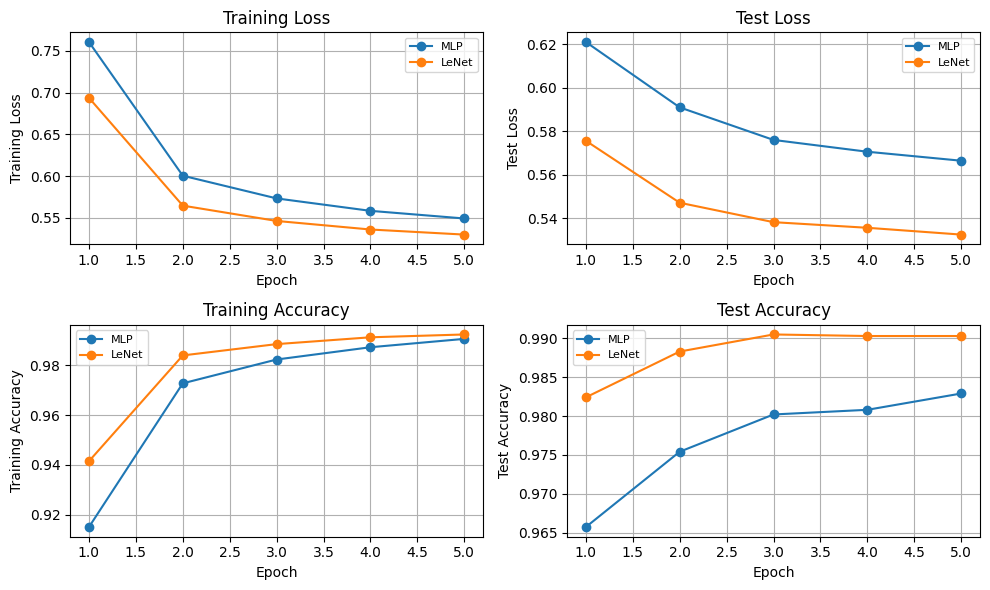

In [ ]:
plot_all_histories(histories)